<a href="https://colab.research.google.com/github/jfleon-dev/university-ai-labs/blob/main/Examen_miner%C3%ADa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examen parcial de Minería de Datos: Análisis Exploratorio de Encuesta Universitaria

En esta actividad trabajarás con una base de datos que contiene información de **700 estudiantes universitarios**.  
El objetivo es realizar un **análisis** para identificar patrones, anomalías y relaciones entre variables.  




## Descripción del dataset

La siguiente tabla muestra la descripción de la base de datos. Se muestran los rangos normales de las variables.

| Columna              | Descripción                                                                 |
|-----------------------|-----------------------------------------------------------------------------|
| **ID**               | Identificador único del estudiante                                          |
| **Carrera**           | Programa académico                               |
| **Semestre**          | Semestre actual (1 a 9)                                                    |
| **Horas_Estudio**     | Horas semanales de estudio (0–30)                   |
| **Horas_Sueño**       | Horas promedio de sueño por día (3–10)              |
| **Uso_Redes_Sociales**| Horas promedio diarias en redes sociales (0–10)     |
| **Actividad_Deportiva** | Participa en actividades deportivas (Sí / No)                           |
| **Calificación_Promedio** | Promedio académico (50–100)|

---

## Preguntas

Justifica cada una de tus respuestas con código.

1. ¿Cuántas carreras se ofrecen en la institución de la encuesta?
2. Existe alguna variable de las que fueron medidas que impacte directamente sobre el promedio de los estudiantes. Justifica tu respuesta.
3. ¿Cuantos valores nulos hay en la tabla?
4. Encuentra y muestra las filas correspondientes a valores fuera de rango en la calificación correspondientes a errores en la transcripción de calificaciones.
5. ¿En qué semestre usan más las redes sociales?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('encuesta_universitaria.csv')
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     700 non-null    int64  
 1   Carrera                700 non-null    object 
 2   Semestre               700 non-null    int64  
 3   Horas_Estudio          698 non-null    float64
 4   Horas_Sueño            694 non-null    float64
 5   Uso_Redes_Sociales     694 non-null    float64
 6   Actividad_Deportiva    700 non-null    object 
 7   Calificación_Promedio  700 non-null    int64  
dtypes: float64(3), int64(3), object(2)
memory usage: 43.9+ KB
None


,ID,Carrera,Semestre,Horas_Estudio,Horas_Sueño,Uso_Redes_Sociales,Actividad_Deportiva,Calificación_Promedio
0,1,Ingeniería Mecánica,9,9.0,4.017406,3.091663,No,61
1,2,Arquitectura,2,11.0,9.704839,4.679204,No,50
2,3,Administración,3,9.0,7.784676,0.502508,No,79
3,4,Ingeniería Mecánica,7,17.0,9.145336,7.962162,Sí,88
4,5,Administración,5,13.0,4.028303,5.308211,No,120


1. ¿Cuántas carreras se ofrecen en la institución de la encuesta?

In [ ]:
total_carreras = df['Carrera'].nunique()
print(f"Se ofrecen {total_carreras} carreras en la institución.")

Se ofrecen 5 carreras en la institución.


Existe alguna variable de las que fueron medidas que impacte directamente sobre el promedio de los estudiantes. Justifica tu respuesta




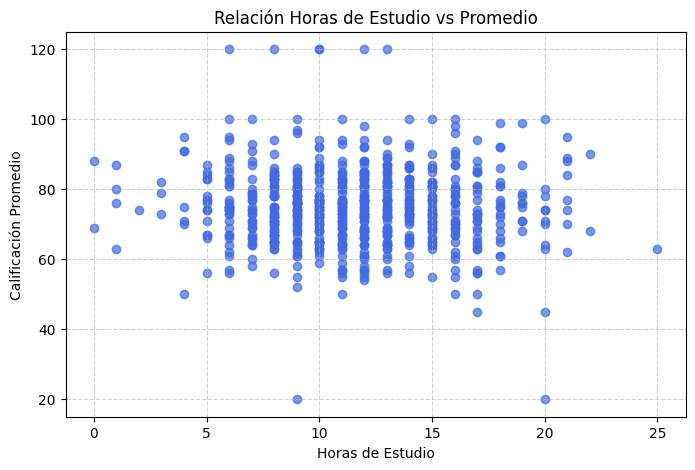

Impacto en el Promedio:
 Calificación_Promedio    1.000000
ID                       0.022539
Horas_Sueño             -0.000728
Semestre                -0.006998
Uso_Redes_Sociales      -0.028682
Horas_Estudio           -0.039656
Name: Calificación_Promedio, dtype: float64


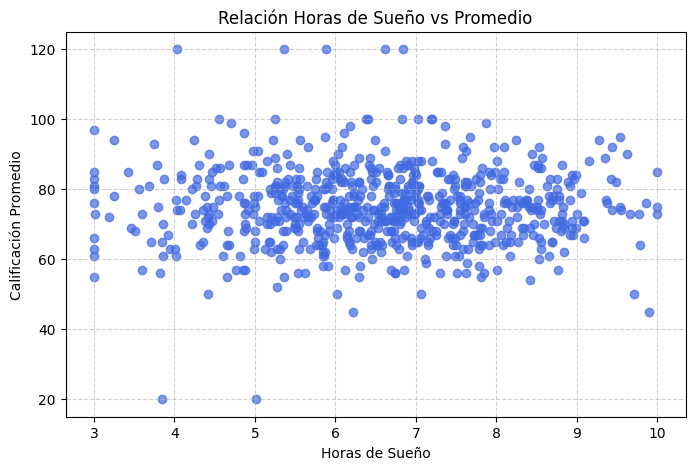

Impacto en el Promedio:
 Calificación_Promedio    1.000000
ID                       0.022539
Horas_Sueño             -0.000728
Semestre                -0.006998
Uso_Redes_Sociales      -0.028682
Horas_Estudio           -0.039656
Name: Calificación_Promedio, dtype: float64
no hay una relacion directa con los resultados


In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df['Horas_Estudio'], df['Calificación_Promedio'], color='royalblue', alpha=0.7)

plt.title('Relación Horas de Estudio vs Promedio')
plt.xlabel('Horas de Estudio')
plt.ylabel('Calificación Promedio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

correlacion = df.corr(numeric_only=True)['Calificación_Promedio'].sort_values(ascending=False)
print("Impacto en el Promedio:\n", correlacion)

plt.figure(figsize=(8, 5))
plt.scatter(df['Horas_Sueño'], df['Calificación_Promedio'], color='royalblue', alpha=0.7)

plt.title('Relación Horas de Sueño vs Promedio')
plt.xlabel('Horas de Sueño')
plt.ylabel('Calificación Promedio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

correlacion2 = df.corr(numeric_only=True)['Calificación_Promedio'].sort_values(ascending=False)
print("Impacto en el Promedio:\n", correlacion2)
print("no hay una relacion directa con los resultados")

3. ¿Cuantos valores nulos hay en la tabla?


In [ ]:
nulos_por_columna = df.isnull().sum()
total_nulos = df.isnull().sum().sum()

print("Valores nulos por columna:\n", nulos_por_columna)
print(f"\nTotal de valores nulos en la tabla: {total_nulos}")

Valores nulos por columna:
 ID                       0
Carrera                  0
Semestre                 0
Horas_Estudio            2
Horas_Sueño              6
Uso_Redes_Sociales       6
Actividad_Deportiva      0
Calificación_Promedio    0
dtype: int64

Total de valores nulos en la tabla: 14


Encuentra y muestra las filas correspondientes a valores fuera de rango en la calificación correspondientes a errores en la transcripción de calificaciones.

In [ ]:
errores_calificacion = df[(df['Calificación_Promedio'] > 100)]

print("Filas con errores de transcripción en Calificación:")
print(errores_calificacion)

Filas con errores de transcripción en Calificación:
      ID                   Carrera  Semestre  Horas_Estudio  Horas_Sueño  \
4      5            Administración         5           13.0     4.028303   
142  143  Sistemas Computacionales         2            8.0     5.364034   
178  179       Ingeniería Mecánica         5           12.0     5.877498   
211  212              Arquitectura         5           10.0          NaN   
606  607  Sistemas Computacionales         5           10.0     6.621060   
679  680              Arquitectura         5            6.0     6.839343   

     Uso_Redes_Sociales Actividad_Deportiva  Calificación_Promedio  
4              5.308211                  No                    120  
142            5.762246                  Sí                    120  
178            0.025320                  Sí                    120  
211            3.640787                  Sí                    120  
606            2.152427                  Sí                    120  
6

¿En qué semestre usan más las redes sociales?


In [ ]:
uso_por_semestre = df.groupby('Semestre')['Uso_Redes_Sociales'].mean()

print(f"Promedio de uso de redes sociales por semestre: \n{uso_por_semestre}")

print(f"El semestre con mayor uso es: {uso_por_semestre.idxmax()}")

Promedio de uso de redes sociales por semestre: 
Semestre
1    3.992496
2    4.468129
3    3.771785
4    3.864698
5    4.056572
6    3.794756
7    4.059605
8    3.596126
9    3.681746
Name: Uso_Redes_Sociales, dtype: float64
El semestre con mayor uso es: 2
